# Exercise 1 - Spectrometre

Name: Kris Su - Remote Sensing of the Environment Fall 2026

![image](./spectrum.png)

In [1]:
from pathlib import Path

import os
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path(os.getcwd())

## Questions

### Question 1 
**What is the purpose of the white reflectance block, and how is it used to calculate % reflectance from a target material? Reproduce this calculation using the raw radiance data from the target and the reference, and verify that your result matches the % reflectance calculated by the spectrometer.**

The white reflectance block is used to establish a baseline reference measurement, assuming it has an approximately 100% reflectance. Measuring the two under the same illumination allows one to calculate the target's % reflectance at each wavelength with respect to the reference block:

$$\% R (\lambda) = \frac{\text{Radiance of the target}} {\text{Radiance of the reference block}} \times 100$$

In [ ]:
folder = cwd / "precollected_ds" / "green_folder.asc" # using the green folder as an example
df_folder = pd.read_csv(folder, skiprows=1, sep=r"\s+", header=None)
wavelength_f, ref_rad_f, tgt_rad_f, ref_f = (df_folder[i] for i in range(4))

# check whether our calculated reflectance matches the instrument output
((tgt_rad_f / ref_rad_f *100).round(2) == ref_f).all() # round to 2 decimal places

np.True_

### Question 2

**Plot the % reflectance profiles of a healthy and a senesced deciduous leaf.  Describe any key differences between these measurements, and save your plot.  Your plot should have axes labels and a legend. Save your plots and include them alongside your answers.**

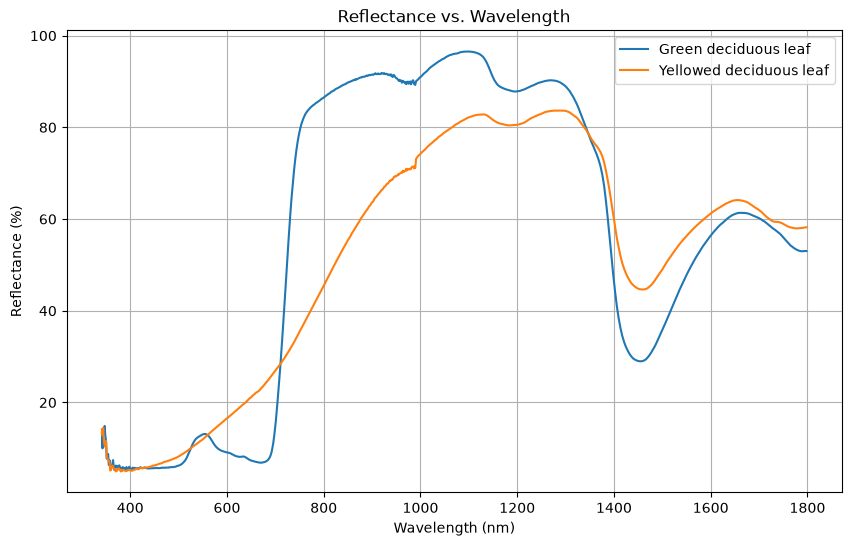

In [5]:
healthy = cwd / "precollected_ds" / "2026 field scans" / "green deciduous leaf.asc"
senesced = cwd / "precollected_ds" / "2026 field scans" / "yellowed deciduous leaf.asc"

df_hd = pd.read_csv(healthy, skiprows=1, sep=r"\s+", header=None)
df_sd = pd.read_csv(senesced, skiprows=1, sep=r"\s+", header=None)


wavelength_hd, _, _, ref_hd = (df_hd[i].to_numpy() for i in range(4))
wavelength_sd, _, _, ref_sd = (df_sd[i].to_numpy() for i in range(4))


# Filter data to limit wavelength to a maximum of 1800 to eliminate noise in the SWIR
filtered_indices_hd = wavelength_hd <= 1800
f_wavelength_hd = wavelength_hd[filtered_indices_hd]
# f_ref_rad_h = ref_rad_h[filtered_indices_h]
# f_tgt_rad_h = tgt_rad_h[filtered_indices_h]
f_ref_hd = ref_hd[filtered_indices_hd]

# Filter for deciduous leaf
filtered_indices_sd = wavelength_sd <= 1800
f_wavelength_sd = wavelength_sd[filtered_indices_sd]
# f_ref_rad_d = ref_rad_d[filtered_indices_d]
# f_tgt_rad_d = tgt_rad_d[filtered_indices_d]
f_ref_sd = ref_sd[filtered_indices_sd]

plt.figure(figsize=(10, 6))
plt.plot(f_wavelength_hd, f_ref_hd, label='Green deciduous leaf')
plt.plot(f_wavelength_sd, f_ref_sd, label='Yellowed deciduous leaf')
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title('Reflectance vs. Wavelength')
plt.grid(True)
plt.legend()
plt.savefig("question_2.png", dpi=300, bbox_inches="tight")
plt.show()

From the plot, the senesced leaf has higher reflectance from around 600 to 700 nm, corresponding to the yellow-to-red portion of the visible spectrum. While the healthy leaf has slightly higher reflectance near the green peak at 550 nm. And a sharper increase around 700-750 nm and higher reflectance across approximately 720-1350 nm. The healthy leaf also has a deeper reflectance minimum near 1450 nm, whereas the senesced leaf generally has higher reflectance from about 1400-1800 nm.

### Question 3

**Plot the % reflectance profile from the green colored folder alongside a reflectance profile from a healthy leaf. Could you distinguish between these objects with a satellite-based spectral sensor? How? [assume that both the leaf and the folder are very large, so that spatial resolution isn’t a concern]**

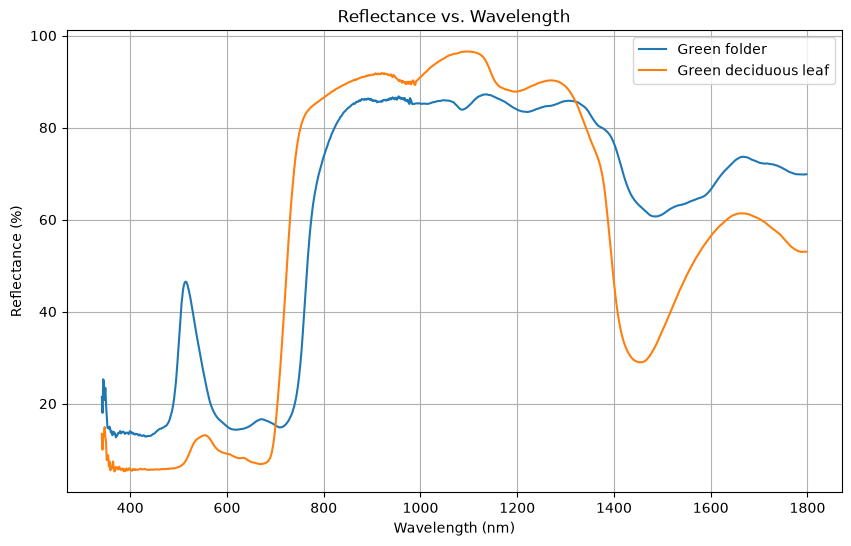

In [20]:
# Filter for the greenfolder to eliminate noise in SWIR
filter_indices_f = wavelength_f <= 1800
f_wavelength_f = wavelength_f[filter_indices_f]
f_ref_f = ref_f[filter_indices_f]

plt.figure(figsize=(10, 6))
plt.plot(f_wavelength_f, f_ref_f, label="Green folder")
plt.plot(f_wavelength_hd, f_ref_hd, label="Green deciduous leaf")
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title('Reflectance vs. Wavelength')
plt.grid(True)
plt.legend()
plt.savefig("question_3.png", dpi=300, bbox_inches="tight")
plt.show()

Due to the artificial dye on the green folder, the green folder generally has higher reflectance than the healthy deciduous leaf in the visible and beyond about 1350 nm, most notably, the folder displays a prominent peak ~500 nm. 


The healthy leaf shows a sharper and earlier increase in reflectance near 700–750 nm and has higher reflectance from ~720 to 1300 nm. But beyond 1400 nm, the folder has higher reflectance.

From a satellite-based sensor could be distinguish the two by looking at their respective visible reflectance range. 

Reflectance near 750 nm would provide strong separation: the leaf reflects approximately 79%, compared with 27% for the folder. Additionally, measurements near 1500 nm could help, since the folder has higher reflectance than the leaf there.


<!-- Beyond ~1400 nm, the folder has higher reflectance. A satellite sensor could distinguish the objects using bands around the red edge and in the near-infrared or shortwave-infrared regions. -->

### Question 4

**Have a look at various spectra of deciduous and evergreen leaves.  Do you think you could distinguish a grove of healthy deciduous plants from a grove of healthy evergreen plants? How?**

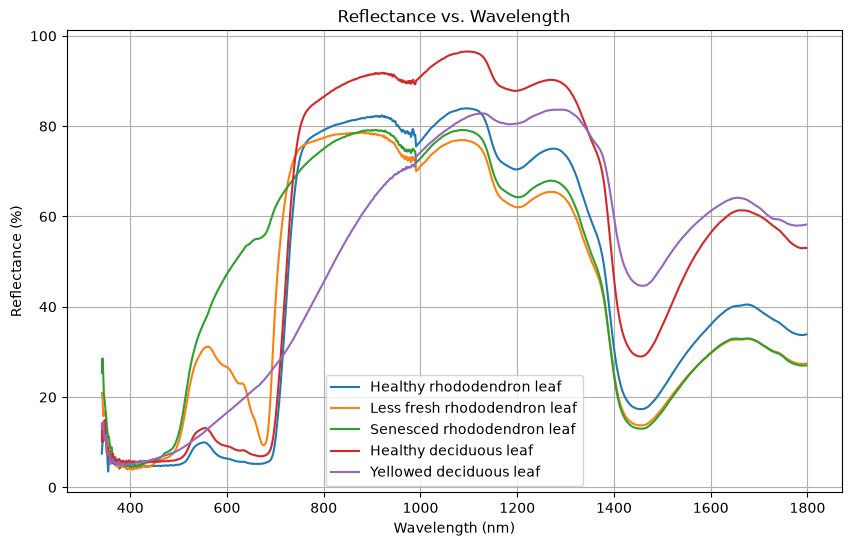

In [8]:
healthy = cwd / "precollected_ds" / "2026 field scans" / "rhododendron healthy.asc"
lfresh = cwd / "precollected_ds" / "2026 field scans" / "rhododendron less fresh.asc"
decidous = cwd / "precollected_ds" / "2026 field scans" / "rhododendron yellow.asc"

df_h = pd.read_csv(healthy, skiprows=1, sep=r"\s+", header=None)
df_lf = pd.read_csv(lfresh, skiprows=1, sep=r"\s+", header=None)
df_d = pd.read_csv(decidous, skiprows=1, sep=r"\s+", header=None)


wavelength_h, _, _, ref_h = (df_h[i].to_numpy() for i in range(4))
wavelength_lf, _, _, ref_lf = (df_lf[i].to_numpy() for i in range(4))
wavelength_d, _, _, ref_d = (df_d[i].to_numpy() for i in range(4))


# Filter data to limit wavelength to a maximum of 1800 to eliminate noise in the SWIR
filtered_indices_h = wavelength_h <= 1800
f_wavelength_h = wavelength_h[filtered_indices_h]
# f_ref_rad_h = ref_rad_h[filtered_indices_h]
# f_tgt_rad_h = tgt_rad_h[filtered_indices_h]
f_ref_h = ref_h[filtered_indices_h]

filtered_indices_lf = wavelength_lf <= 1800
f_wavelength_lf = wavelength_lf[filtered_indices_lf]
# f_ref_rad_d = ref_rad_d[filtered_indices_d]
# f_tgt_rad_d = tgt_rad_d[filtered_indices_d]
f_ref_lf = ref_lf[filtered_indices_lf]

filtered_indices_d = wavelength_d <= 1800
f_wavelength_d = wavelength_d[filtered_indices_d]
# f_ref_rad_d = ref_rad_d[filtered_indices_d]
# f_tgt_rad_d = tgt_rad_d[filtered_indices_d]
f_ref_d = ref_d[filtered_indices_d]

plt.figure(figsize=(10, 6))
plt.plot(f_wavelength_h, f_ref_h, label='Healthy rhododendron leaf')
plt.plot(f_wavelength_lf, f_ref_lf, label='Less fresh rhododendron leaf')
plt.plot(f_wavelength_d, f_ref_d, label='Senesced rhododendron leaf')
plt.plot(f_wavelength_hd, f_ref_hd, label='Healthy deciduous leaf')
plt.plot(f_wavelength_sd, f_ref_sd, label='Yellowed deciduous leaf')
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title('Reflectance vs. Wavelength')
plt.grid(True)
plt.legend()
plt.savefig("question_4.png", dpi=300, bbox_inches="tight")
plt.show()

A healthy deciduous grove could potentially be distinguished from a healthy evergreen grove using differences in their near-infrared and shortwave-infrared reflectance. 

In these measurements, the healthy deciduous leaf has higher reflectance than the healthy rhododendron leaf: approximately 91% versus 76% near 1000 nm, and 56% versus 36% near 1600 nm.

However, their reflectance profile may overlap during the growing season, also when remotely sensing trees, leaf measurements shown above do not guarantee the same separation at grove scale, where canopy structure, shadows, and ground cover also influence reflectance.

So seasonal satellite observations could help distinguish a grove of deciduous from evergreen, since the former would lose their leaves.

### Question 5

**Plot the profile of the shallow and deep water samples that we recorded for you in the lab. Note that these measurements were taken by pouring tap water into a clear glass bowl, placed on top of the white reference block, so you might want to look at the glass bowl measurement as well. What is your interpretation of this measurement?**

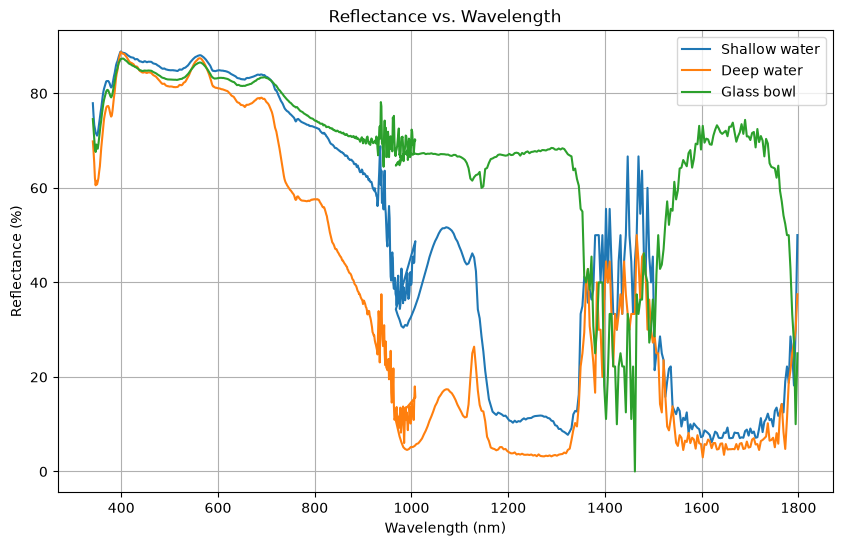

In [14]:
shallow_h2o = cwd / "precollected_ds" / "shallow water.asc"
deep_h2o = cwd / "precollected_ds" / "deep water.asc"
bowl = cwd / "precollected_ds" / "glass bowl.asc"

df_h2o_s = pd.read_csv(shallow_h2o, skiprows=1, sep=r"\s+", header=None)
df_h2o_d = pd.read_csv(deep_h2o, skiprows=1, sep=r"\s+", header=None)
df_bowl = pd.read_csv(bowl, skiprows=1, sep=r"\s+", header=None)

lambda_s, _, _, ref_h2o_s = (df_h2o_s[i] for i in range(4))
lambda_d, _, _, ref_h2o_d = (df_h2o_d[i] for i in range(4))
lambda_b, _, _, ref_bowl = (df_bowl[i] for i in range(4))

# Filter data to eliminate noise in SWIR
filter_indices_sh2o = lambda_s <= 1800
f_lambda_s = lambda_s[filter_indices_sh2o]
f_ref_sh2o = ref_h2o_s[filter_indices_sh2o]

filter_indices_dh2o = lambda_d <= 1800
f_lambda_d = lambda_d[filter_indices_dh2o]
f_ref_dh2o = ref_h2o_d[filter_indices_dh2o]

filter_indices_bowl = lambda_b <= 1800
f_lambda_bowl = lambda_b[filter_indices_bowl]
f_ref_bowl = ref_bowl[filter_indices_bowl]

plt.figure(figsize=(10, 6))
plt.plot(f_lambda_s, f_ref_sh2o, label='Shallow water')
plt.plot(f_lambda_d, f_ref_dh2o, label='Deep water')
plt.plot(f_lambda_bowl, f_ref_bowl, label='Glass bowl')
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title('Reflectance vs. Wavelength')
plt.grid(True)
plt.legend()
plt.savefig("question_5.png", dpi=300, bbox_inches="tight")
plt.show()

Both water samples have high apparent reflectance in the visible spectrum, similar to the glass bowl. At longer wavelengths, the water samples appears to have lower reflectance than the glass bowl. Meanwhile, deep water has lower reflectance than shallow water because the longer path through water allows more light to be absorbed. 

For example, near 1200 m, glass bowl has ~70% reflectance, but 11% for shallow water, and 4% for deep water. Yet, these measurements therefore represent the combined water-bowl-block system, than simply water alone.

### Question 6

**It’s too warm for snow right now, so we weren’t able to collect any measurements ourselves. But there are spectral signatures for fine-grained snow and coarse-grained snow that were collected a number of years ago at JHU** and contributed to the NASA ASTER/ECOSTRESS spectral library (http://speclib.jpl.nasa.gov/).

Go to Search Library and look for Spectral Type “Water,” then click view_plot for Fine Snow (and then Coarse Granular Snow). You can download the data file by selecting “View Data File” and then right clicking to “save as” a text file or just copying the text into your own text editor. The files are space-delimited text files that report % reflectance for each wavelength. You can modify the Python code to read them in (you will need to change several elements of the read command; you can also edit the data file header to facilitate import), or just do the work in Excel or a similar program.  

**Plot the two profiles. If you were designing a satellite sensor to distinguish between different types of snow, what portions of the spectrum would you want to measure?**

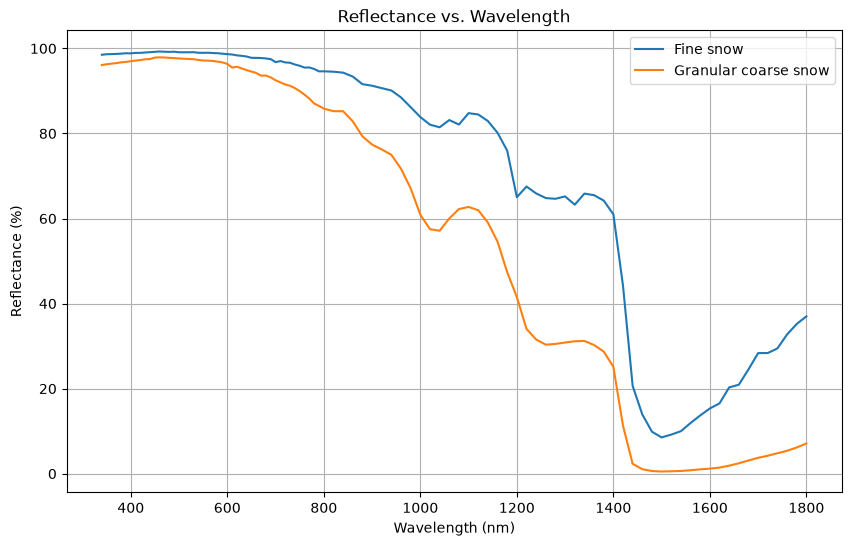

In [ ]:
file1 = cwd / "precollected_ds" / "fine snow.txt"
file2 = cwd / "precollected_ds" / "coarse snow.txt"


fine_snow = pd.read_csv(file1, sep=r'\s+', header=None)
coarse_snow = pd.read_csv(file2, sep=r'\s+', header=None)


lambda_fs, ref_fs = (fine_snow[i].to_numpy() for i in range(2))
lambda_cs, ref_cs = (coarse_snow[i].to_numpy() for i in range(2))

# Filter data to eliminate noise 
filter_indices_fs = lambda_fs*1000 <= 2500
f_lambda_fs = lambda_fs[filter_indices_fs]*1000
f_ref_fs = ref_fs[filter_indices_fs]

filter_indices_cs = lambda_cs*1000 <= 2500
f_lambda_cs = lambda_cs[filter_indices_cs]*1000
f_ref_cs = ref_cs[filter_indices_cs]

plt.figure(figsize=(10, 6))
plt.plot(f_lambda_fs, f_ref_fs, label="Fine snow")
plt.plot(f_lambda_cs, f_ref_cs, label="Granular coarse snow")
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title("Reflectance vs. Wavelength")
plt.grid(True)
plt.legend()
plt.savefig("question_6.png", dpi=300, bbox_inches="tight")
plt.show()

The shape of their spectra looks similar, having almost similar reflectance near at 500 nm. Both show a pronounced dip near 1500 nm caused by absorption by water molecules. However, fine snow show higher reflectance than coarse snow, especially in the the infrared. 


<!-- however, they differ with respect to the magnitude of reflectance. Fine snow appears to have higher reflectance than coarse snow throughout. But note that, their reflectance is close at ~500 nm.  -->

To distinguish between these two types of snow, the satellite instrument could measure near-infrared wavelengths around 1000~1300 nm and shortwave-infrared wavelengths around 1600-1700 nm, where the spectra differ substantially. For example, at 1300 nm, fine snow more than 60% whereas coarse snow is only half than that.

### Question 7 

Another major application of reflectance spectroscopy is soil and mineral identification. For example, calcite (limestone), gypsum and halite often look similar to the naked eye because they are all bright white. The files calcite.txt, gypsum_sand.txt, and halite.txt contain NASA ASTER/ECOSTRESS spectral library measurements for these three mineral types. **Plot their reflectance profiles and describe how remote sensing could be used to distinguish between these minerals.** This particular distinction is very important both for geological mapping (especially for Mars!) and for agricultural applications (soil constituents).  **Which of these would likely be hardest to detect on Mars, and why?**

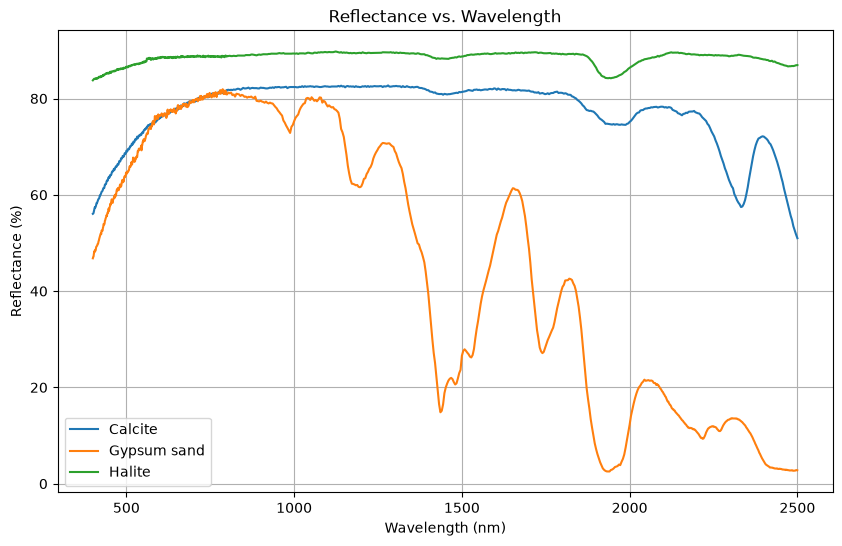

In [15]:
calcite = cwd / "precollected_ds" / "HaliteCalciteGypsum" / "calcite.txt"
gypsum_sand = cwd / "precollected_ds" / "HaliteCalciteGypsum" / "gypsum_sand.txt"
halite = cwd / "precollected_ds" / "HaliteCalciteGypsum" / "halite.txt"

df_c = pd.read_csv(calcite, sep=r'\s+', header=None)
df_g = pd.read_csv(gypsum_sand, sep=r'\s+', header=None)
df_h = pd.read_csv(halite, sep=r'\s+', header=None)

lambda_c, ref_c = (df_c[i].to_numpy() for i in range(2))
lambda_g, ref_g = (df_g[i].to_numpy() for i in range(2))
lambda_h, ref_h = (df_h[i].to_numpy() for i in range(2))

# Filter data to eliminate noise in SWIR
filter_indices_c = lambda_c*1000 <= 2500
f_lambda_c = lambda_c[filter_indices_c]*1000
f_ref_c = ref_c[filter_indices_c]

filter_indices_g = lambda_g*1000 <= 2500
f_lambda_g = lambda_g[filter_indices_g]*1000
f_ref_g = ref_g[filter_indices_g]

filter_indices_h = lambda_h*1000 <= 2500
f_lambda_h = lambda_h[filter_indices_h]*1000
f_ref_h = ref_h[filter_indices_h]

plt.figure(figsize=(10, 6))
plt.plot(f_lambda_c, f_ref_c, label="Calcite")
plt.plot(f_lambda_g, f_ref_g, label="Gypsum sand")
plt.plot(f_lambda_h, f_ref_h, label="Halite")
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title("Reflectance vs. Wavelength")
plt.grid(True)
plt.legend()
plt.savefig("question_7.png", dpi=300, bbox_inches="tight")
plt.show()

Remote sensing could be used to detect these minerals by looking at their reflectance in respective wavelength.

The hardest mineral to detect is halite, since it reflectance in most wavelength, and does not have a characteristic absorption behaviors. Brightness alone is not a unique identifier, especially when minerals are mixed. In contrast, calcite has a prominent dip near 2340 nm in the supplied data, while halite remains relatively bright and featureless.

On the other hand, gypsum sand should be the easiest to detected among the three, as it shows strong absorption features, dips around 1400-1500 nm and 1900-2000 nm. 

### Question 8

**Continuing to look at the plot of calcite, gypsum, and halite, compare back to the plot of fine snow – what do you notice about these four spectra?  Are they generally similar, or different, and why do you think this is?**

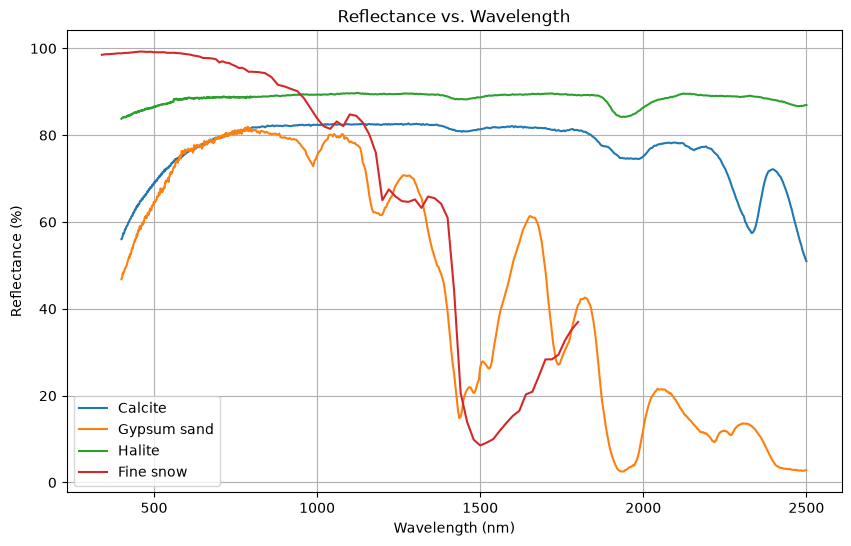

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(f_lambda_c, f_ref_c, label="Calcite")
plt.plot(f_lambda_g, f_ref_g, label="Gypsum sand")
plt.plot(f_lambda_h, f_ref_h, label="Halite")
plt.plot(f_lambda_fs, f_ref_fs, label="Fine snow")
plt.xlabel('Wavelength (nm)')
plt.ylabel("Reflectance (%)")
plt.title("Reflectance vs. Wavelength")
plt.grid(True)
plt.legend()
plt.savefig("question_8.png", dpi=300, bbox_inches="tight")
plt.show()

All four materials have relatively high visible reflectance, consistent with their white appearance but their infrared spectra differ substantially.

Fine snow and gypsum both show strong absorption around 1400–1500 nm, likely associate with the water molecules inside. Therefore, their absorption features are similar but not identical.

Calcite has a distinctive absorption near 2340 nm, while halite remains relatively bright and featureless across the plotted range. These differences reflect their different compositions and molecular structures.

### Question 9 

**Search the internet for the wavelength bands of the Earth based ASTER (VNIR and SWIR only) and the Mars based CRISM instruments – what are these wavelength bands, and why do you think these specific bands were chosen?**

<!-- the VNIR spectral is 0.52 - 0.86  µm and the SWIR spectral is 1.60 - 2.43 µm. -->
<!-- - Band 4: 1.600–1.700 µm
- Band 5: 2.145–2.185 µm
- Band 6: 2.185–2.225 µm
- Band 7: 2.235–2.285 µm
- Band 8: 2.295–2.365 µm
- Band 9: 2.360–2.430 µm -->

According to [NASA](https://www.earthdata.nasa.gov/data/instruments/aster), The Earth-based ASTER instrument has three visible-NIR bands:
- Band 1: 0.52–0.60 µm | Band 2: 0.63–0.69 µm | Band 3: 0.76–0.86 µm

And it also has six SWIR bands, covering the wavelength from 1.60 µm up to 2.43 µm. 

On the other hand, the APL [CRISM site](http://crism.jhuapl.edu/instrument/design/specifications.php) says its VNIR detector covers 0.36-1.05 µm, while its IR detector covers 1.00-3.92 µm. However, they also note that these are the fall range of band, the NASA website noted the CRISM's most useful VNIR and IR ranges are 410-1020 nm and 1030-3920 nm respectively.

The bands of the these two instrument are chosen differently could be due to that the remote sensing task various for different planets. For Earth, ASTER's bands were selected to measure vegetation and iron oxides in the VNIR and to distinguish rocks and minerals in the SWIR. The bands also occur mainly within atmospheric transmission windows. But a broad spectral coverage allows CRISM to identify iron-bearing minerals, silicates, water-bearing minerals from their absorption features. These minerals provide evidence about Mars' paleo-climate.


<!-- CRISM covers approximately 0.362–3.920 µm using 544 narrow spectral channels. Its VNIR detector covers 0.36–1.05 µm, while its IR detector covers 1.00–3.92 µm.  -->


 <!-- for Earth based observation one be more interested in looking at the visible and IR range to look for changes, whereas for Mars, assuming that researchers are  more interested in the planet's paleoclimte, so the IR band is from 1 to 3.92 microns, detecting for the sign of water [espcially water dips in NIR range]. -->